# Click Prediction with MLP: Scikit-learn vs PySpark

Diccionario de Variables

A continuación se describen las variables utilizadas en el dataset para la predicción de clics en anuncios móviles:

| Variable            | Tipo      | Descripción |
|--------------------|----------|------------|
| **id**             | Entera  | Identificador único de la impresión del anuncio |
| **click**          | Entera  | Variable objetivo: 1 = clic, 0 = no clic |
| **hour**           | Entera  | Fecha y hora de la impresión (formato YYMMDDHH) |
| **C1**             | Entera  | Variable categórica anonimizada |
| **banner_pos**     | Entera  | Posición del banner en la pantalla |
| **site_id**        | Categórica    | Identificador del sitio web |
| **site_domain**    | Categórica    | Dominio del sitio web |
| **site_category**  | Categórica   | Categoría del sitio web |
| **app_id**         | Categórica   | Identificador de la aplicación |
| **app_domain**     | Categórica   | Dominio de la aplicación |
| **app_category**   | Categórica   | Categoría de la aplicación |
| **device_id**      | Categórica   | Identificador del dispositivo |
| **device_ip**      | Categórica   | Dirección IP del dispositivo |
| **device_model**   | Categórica   | Modelo del dispositivo |
| **device_type**    | Entera    | Tipo de dispositivo |
| **device_conn_type** | Entera  | Tipo de conexión del dispositivo |
| **C14 – C21**      | Entera    | Variables categóricas anonimizada adicionales |

---

In [1]:
import os
import gc
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
DATA_DIR = r"C:\Users\camil\Documents\Estudio\DL\Corte1\Dataset\avazu-ctr-prediction"

TRAIN_PATH = os.path.join(DATA_DIR, "train.gz")
TEST_PATH = os.path.join(DATA_DIR, "test.gz")
SUB_PATH = os.path.join(DATA_DIR, "sampleSubmission.gz")

# ==============================
# ⚡ Carga eficiente (por chunks + muestreo)
# ==============================
CHUNKSIZE = 1_000_000
SAMPLE_FRAC = 0.05  # 5% de cada chunk

chunks = []

for chunk in pd.read_csv(TRAIN_PATH, compression='gzip', chunksize=CHUNKSIZE):
    chunks.append(chunk.sample(frac=SAMPLE_FRAC, random_state=42))

df = pd.concat(chunks, axis=0)

# Liberar memoria
del chunks
gc.collect()

20

In [11]:
df["dct_cat"] = df["device_conn_type"].map({0: "0", 1: "1", 2: "2", 3: "3", 4: "4", 5: "5"})
df["dt_cat"] = df["device_type"].map({0: "0", 1: "1", 2: "2", 3: "3", 4: "4", 5: "5"})

In [12]:
print("Shape:", df.shape)
df.head()

Shape: (2021448, 27)


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,C15,C16,C17,C18,C19,C20,C21,click_cat,dct_cat,dt_cat
987231,1.396622e+19,0,14102105,1005,0,85f751fd,c4e18dd6,50e219e0,f0d41ff1,2347f47a,...,320,50,2494,3,35,-1,112,No Click,0,1
79954,4.513347e+18,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,320,50,1722,0,35,100084,79,No Click,2,1
567130,2.268430e+18,0,14102103,1005,1,856e6d3f,58a89a43,f028772b,ecad2386,7801e8d9,...,320,50,1800,3,167,-1,23,No Click,0,1
500891,1.318598e+19,0,14102103,1005,0,85f751fd,c4e18dd6,50e219e0,d8784af5,2347f47a,...,320,50,2201,3,35,-1,43,No Click,0,1
55399,1.772018e+19,1,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,3ebe76e6,2347f47a,...,320,50,112,3,1319,-1,15,Click,2,1


Contamos con un total de 14 varibles de tipo entero y 9 de tipo categórica, lo que nos deja con un total de 25 variables disponibles en el dataset

In [13]:
df.isnull().sum()

id                  0
click               0
hour                0
C1                  0
banner_pos          0
site_id             0
site_domain         0
site_category       0
app_id              0
app_domain          0
app_category        0
device_id           0
device_ip           0
device_model        0
device_type         0
device_conn_type    0
C14                 0
C15                 0
C16                 0
C17                 0
C18                 0
C19                 0
C20                 0
C21                 0
click_cat           0
dct_cat             0
dt_cat              0
dtype: int64

No encontramos resultados de valores faltantes en el dataset por lo que omitimos procesos de imputación por NAs

In [14]:
df.describe()

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
count,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06,2.021448e+06
mean,9.222259e+18,1.694033e-01,1.410256e+07,1.004969e+03,2.882839e-01,1.015626e+00,3.306293e-01,1.884567e+04,3.188916e+02,6.007346e+01,2.113113e+03,1.433119e+00,2.274716e+02,5.320464e+04,8.337919e+01
std,5.326302e+18,3.751079e-01,2.966843e+02,1.095737e+00,5.058533e-01,5.281608e-01,8.544581e-01,4.953524e+03,2.124275e+01,4.722034e+01,6.087835e+02,1.326052e+00,3.512635e+02,4.995758e+04,7.027638e+01
min,1.242934e+13,0.000000e+00,1.410210e+07,1.001000e+03,0.000000e+00,0.000000e+00,0.000000e+00,3.750000e+02,1.200000e+02,2.000000e+01,1.120000e+02,0.000000e+00,3.300000e+01,-1.000000e+00,1.000000e+00
25%,4.607790e+18,0.000000e+00,1.410230e+07,1.005000e+03,0.000000e+00,1.000000e+00,0.000000e+00,1.692000e+04,3.200000e+02,5.000000e+01,1.863000e+03,0.000000e+00,3.500000e+01,-1.000000e+00,2.300000e+01
50%,9.222765e+18,0.000000e+00,1.410260e+07,1.005000e+03,0.000000e+00,1.000000e+00,0.000000e+00,2.034600e+04,3.200000e+02,5.000000e+01,2.323000e+03,2.000000e+00,3.900000e+01,1.000480e+05,6.100000e+01
75%,1.383463e+19,0.000000e+00,1.410281e+07,1.005000e+03,1.000000e+00,1.000000e+00,0.000000e+00,2.189400e+04,3.200000e+02,5.000000e+01,2.526000e+03,3.000000e+00,1.710000e+02,1.000900e+05,1.010000e+02
max,1.844674e+19,1.000000e+00,1.410302e+07,1.012000e+03,7.000000e+00,5.000000e+00,5.000000e+00,2.405200e+04,1.024000e+03,1.024000e+03,2.758000e+03,3.000000e+00,1.839000e+03,1.002480e+05,2.550000e+02


In [15]:
df.describe(include='object')

,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,click_cat,dct_cat,dt_cat
count,2021448,2021448,2021448,2021448,2021448,2021448,2021448,2021448,2021448,2021448,2021448,2021448
unique,3028,3534,22,3919,250,27,280470,969993,5787,2,4,5
top,85f751fd,c4e18dd6,50e219e0,ecad2386,7801e8d9,07d7df22,a99f214a,6b9769f2,8a4875bd,No Click,0,1
freq,728950,755692,825932,1292498,1362867,1309029,1667942,10487,122759,1679008,1745061,1865111


In [16]:
df.select_dtypes(include='object').nunique().sort_values(ascending=False)

device_ip        969993
device_id        280470
device_model       5787
app_id             3919
site_domain        3534
site_id            3028
app_domain          250
app_category         27
site_category        22
dt_cat                5
dct_cat               4
click_cat             2
dtype: int64

Se observa que varias variables presentan una alta cardinalidad, especialmente `device_ip`, `device_id`, `device_model`, `app_id` y `site_domain`, lo que refleja una gran cantidad de valores únicos asociados a usuarios, dispositivos y contextos de navegación. Este comportamiento es característico en datos de publicidad digital y resulta coherente, ya que muchas de estas variables corresponden a identificadores únicos que, por naturaleza, presentan baja repetición. Por otro lado, variables como `app_category`, `click`, `device_type` , `device_conn_type` y `site_category` muestran baja cardinalidad, lo que facilita su análisis e interpretación. Adicionalmente, es importante considerar que existen variables categóricas codificadas como enteros, que fueron tratadas a categoricas como `click`, `device_type` y `device_conn_type`, para el correcto análisis

## EDA

In [7]:
df["click"].value_counts()

click
0    1679008
1     342440
Name: count, dtype: int64

C:\Users\camil\AppData\Local\Temp\ipykernel_20828\1001510359.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Text(0, 0.5, 'Frecuencia')

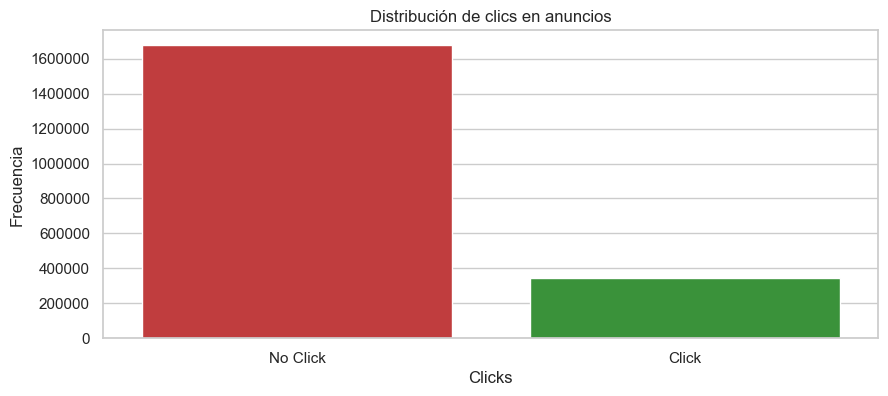

In [8]:
df["click_cat"] = df["click"].map({0: "No Click", 1: "Click"})
sns.countplot(
    x="click_cat",
    data=df,
    palette={"No Click": "#d62728", "Click": "#2ca02c"}
)
plt.ticklabel_format(style="plain", axis="y")
plt.title("Distribución de clics en anuncios")
plt.xlabel("Clicks")
plt.ylabel("Frecuencia")

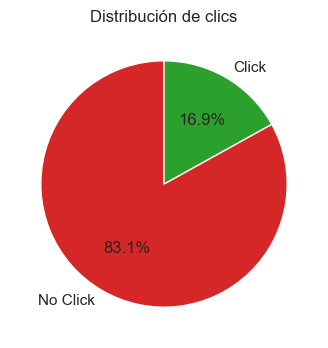

In [9]:
counts = df["click"].value_counts()

plt.pie(
    counts,
    labels=["No Click", "Click"],
    autopct="%1.1f%%",
    colors=["#d62728", "#2ca02c"],
    startangle=90
)

plt.title("Distribución de clics")
plt.show()

Encontramos que la variable objetivo se encuentra claramente desproporcionada, teniendo mas de 16M de casos en los qué no se da click aproximadamente 3.5M millones de casos en los que no se da click a la publicidad generada, podemos decir que si el objetivo de la publicidad generada sea dar click solamente está teniendo un 17% de éxito aproximadamente

Text(0.5, 1.0, 'Distribución de los dispositivos')

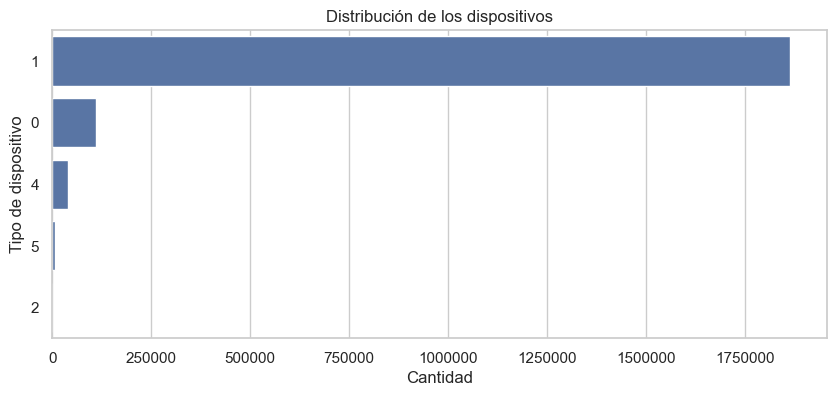

In [17]:
sns.countplot(df.dt_cat)
plt.ticklabel_format(style= "plain", axis= "x")
plt.xlabel("Cantidad")
plt.ylabel("Tipo de dispositivo")
plt.title("Distribución de los dispositivos")


La cantidad de dispostivios registrados tiene un total redondeado de 2M, dividido en 5 tipos de categorías siendo la predominamente el tipo de dispositivo 1 con alrededorede 1.8M de registros mientras que los dispositivos 0 y 4 tienen una cantidad menor a 125K dispostivos y finalmente los dispositivos tipo 2 y 5 tienen registros casi nulos en comparación a la cantidad de los otros

Text(0.5, 1.0, 'Distribución de los la conexión de los dispositivos')

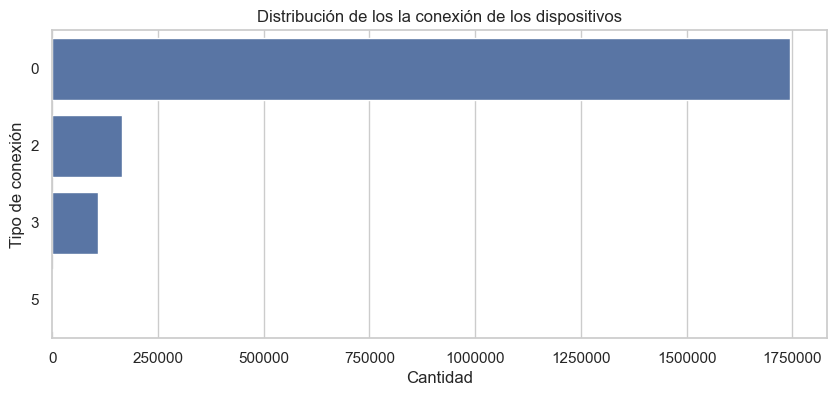

In [18]:
sns.countplot(df.dct_cat)
plt.ticklabel_format(style= "plain", axis= "x")
plt.xlabel("Cantidad")
plt.ylabel("Tipo de conexión")
plt.title("Distribución de los la conexión de los dispositivos")


La cantidad de tipos de conexiones de dispositivos registradas tiene un total de 2M redondeando contando con el tipo predominante el conexión tipo 0 que tiene aproximadamente 1.75M de registros, mientras que los conexiones de tipo 2 y 3 tienen un cantidad menor a 250k y mientras que la conexiones 1 y 5 tienen registros nulos o casi nulos

In [25]:
df["datetime"] = pd.to_datetime(df["hour"], format="%y%m%d%H")
df["day_week"] = df["datetime"].dt.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["hour_day"] = df["hour"] % 100

# Franja horaria
def franja(h):
    if 6 <= h < 12:
        return "Mañana"
    elif 12 <= h < 18:
        return "Tarde"
    elif 18 <= h < 24:
        return "Noche"
    else:
        return "Madrugada"

df["franja"] = df["hour_day"].apply(franja)

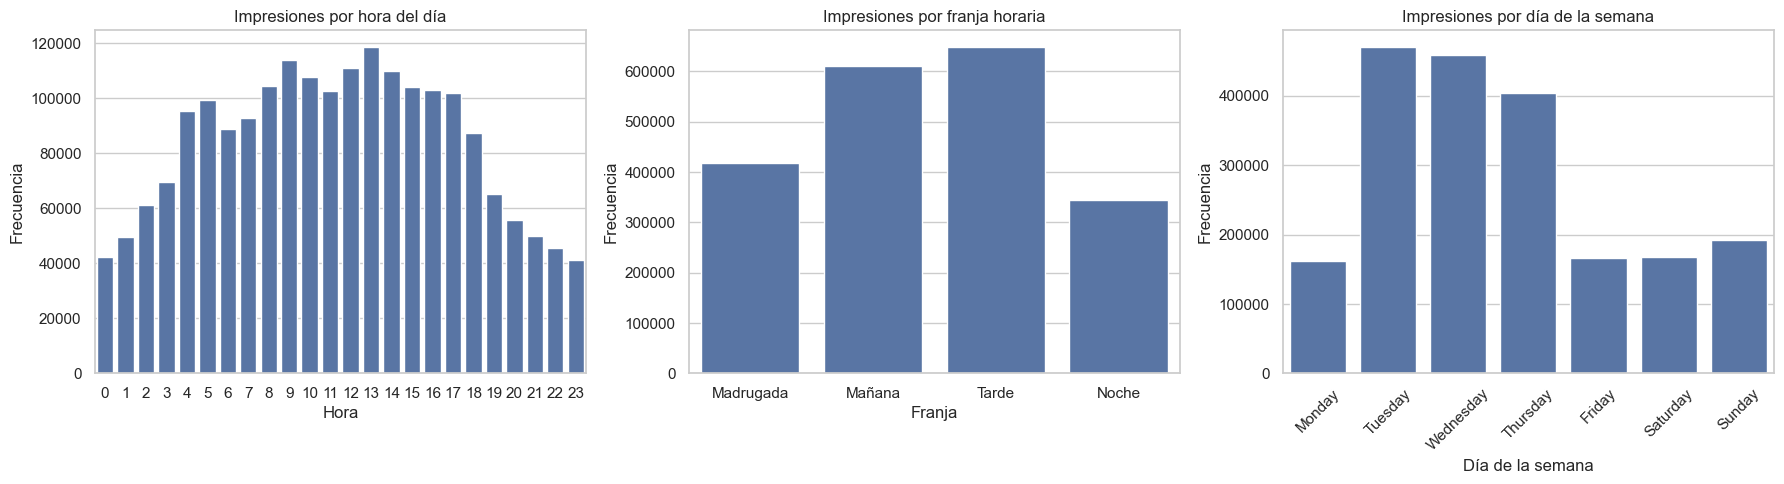

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# =========================
# 1. Impresiones por hora
# =========================
sns.countplot(x="hour_day", data=df, ax=axes[0])
axes[0].set_title("Impresiones por hora del día")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("Frecuencia")

# =========================
# 2. Impresiones por franja
# =========================
sns.countplot(
    x="franja",
    data=df,
    order=["Madrugada", "Mañana", "Tarde", "Noche"],
    ax=axes[1]
)
axes[1].set_title("Impresiones por franja horaria")
axes[1].set_xlabel("Franja")
axes[1].set_ylabel("Frecuencia")

# =========================
# 3. Impresiones por día de la semana
# =========================
sns.countplot(x="day_week", data=df, order=order, ax=axes[2])

axes[2].set_title("Impresiones por día de la semana")
axes[2].set_xlabel("Día de la semana")
axes[2].set_ylabel("Frecuencia")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Se observa que la mayor cantidad de impresiones publicitarias se concentra entre las franjas de la mañana y la tarde, mientras que durante la noche se registra un menor volumen. Este comportamiento es consistente con los patrones de actividad humana, ya que durante el día los usuarios interactúan más con dispositivos digitales, mientras que en horas nocturnas la actividad disminuye debido a periodos de descanso. Asimismo, se identifica que los días con mayor volumen de impresiones corresponden a martes, miércoles y jueves, lo que sugiere un incremento en la actividad a mitad de semana, probablemente asociado a rutinas laborales y mayor uso de plataformas digitales.

In [29]:
df.groupby("device_type")["click"].mean()
df.groupby("device_conn_type")["click"].mean()
df.groupby("banner_pos")["click"].mean()
df.groupby("franja")["click"].mean()

franja
Madrugada    0.170198
Mañana       0.165854
Noche        0.165156
Tarde        0.174486
Name: click, dtype: float64

In [31]:
ctr_global = df["click"].mean()
print(f"CTR global: {ctr_global:.4f} ({ctr_global:.2%})")

CTR global: 0.1694 (16.94%)


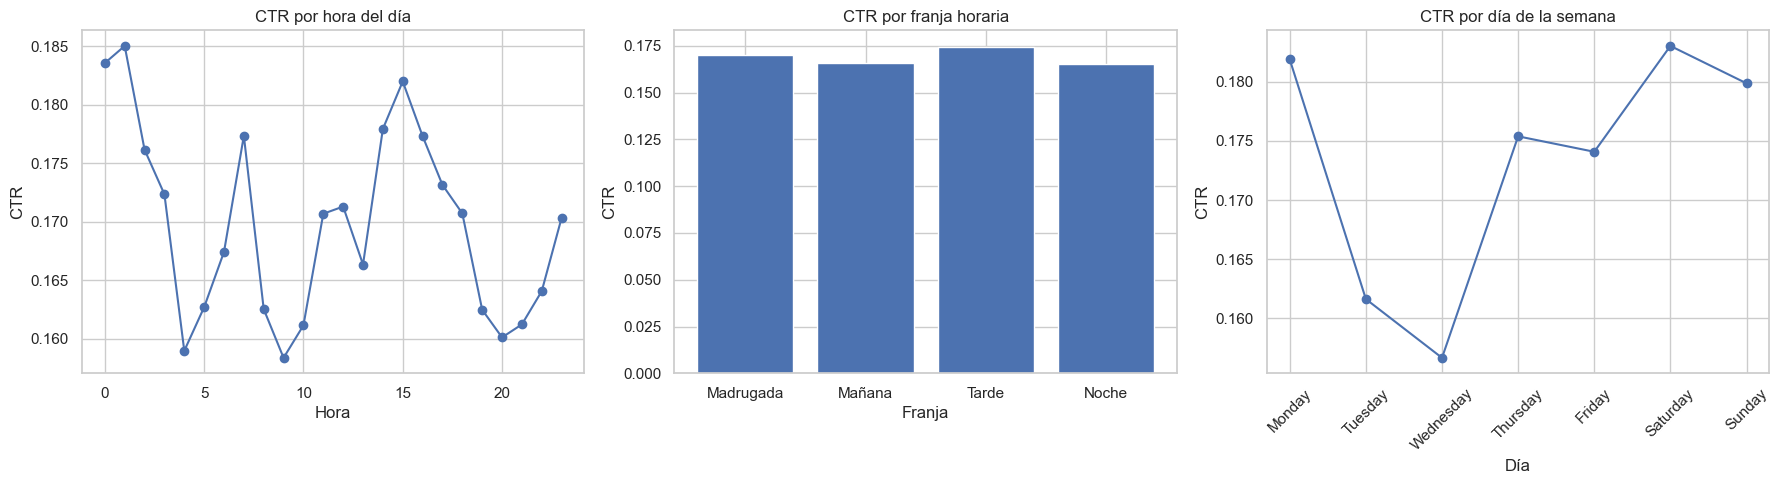

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# =========================
# 1. CTR por hora
# =========================
ctr_hour = df.groupby("hour_day")["click"].mean()

axes[0].plot(ctr_hour.index, ctr_hour.values, marker='o')
axes[0].set_title("CTR por hora del día")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("CTR")
axes[0].grid(True)

# =========================
# 2. CTR por franja
# =========================
ctr_franja = df.groupby("franja")["click"].mean().reindex(
    ["Madrugada", "Mañana", "Tarde", "Noche"]
)

axes[1].bar(ctr_franja.index, ctr_franja.values)
axes[1].set_title("CTR por franja horaria")
axes[1].set_xlabel("Franja")
axes[1].set_ylabel("CTR")

# =========================
# 3. CTR por día de la semana
# =========================
ctr_week = df.groupby("day_week")["click"].mean().reindex(order)

axes[2].plot(ctr_week.index, ctr_week.values, marker='o')
axes[2].set_title("CTR por día de la semana")
axes[2].set_xlabel("Día")
axes[2].set_ylabel("CTR")
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True)

plt.tight_layout()
plt.show()